# Data Information
- This notebook trains a k-nearest neighbour model which contains movie reviews with a positive or negative label
- We then improve the accuracy of the k-nearest neighbour model and train/test it again using the full IMDB dataset

### Install sklearn: python library for machine learning

In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


### Install datasets: access IMDB dataset

In [2]:
pip install datasets

Note: you may need to restart the kernel to use updated packages.


In [3]:
from datasets import load_dataset

imdb_dataset = load_dataset("imdb")["train"]
print(imdb_dataset[-1])

{'text': 'The story centers around Barry McKenzie who must go to England if he wishes to claim his inheritance. Being about the grossest Aussie shearer ever to set foot outside this great Nation of ours there is something of a culture clash and much fun and games ensue. The songs of Barry McKenzie(Barry Crocker) are highlights.', 'label': 1}


### Look at IMDB reviews in DataFrame

In [4]:
import pandas as pd
df = pd.DataFrame(imdb_dataset)

print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
df.head()

Number of rows: 25000
Number of columns: 2


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


### Convert training data into format scikit-learn expects
- Input vectors (documents) and a list of associated output labels

In [5]:
train_data = []
train_data_labels = []
for item in imdb_dataset:
    train_data.append(item["text"])
    train_data_labels.append(item["label"])

print(train_data[5])
print(train_data_labels[5])

I would put this at the top of my list of films in the category of unwatchable trash! There are films that are bad, but the worst kind are the ones that are unwatchable but you are suppose to like them because they are supposed to be good for you! The sex sequences, so shocking in its day, couldn't even arouse a rabbit. The so called controversial politics is strictly high school sophomore amateur night Marxism. The film is self-consciously arty in the worst sense of the term. The photography is in a harsh grainy black and white. Some scenes are out of focus or taken from the wrong angle. Even the sound is bad! And some people call this art?<br /><br />
0


This is a film review and its label. We can clearly see that this is a negative film review. We see this with key phrases such as:\
"unwatchable trash",\
"Even the sound is bad!"\
"And some people call this art?"

The label for this review is 0. We can assume: 1 = positive review | 0 = negative review

### Import CountVectorizer
- Use the CountVectorizer class to extract the words in each review as the features the algorithm will learn from.
- Each document is represented as a 500 dimension vector of word counts. Only the 500 most frequent words are used in this version.

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(analyzer="word", max_features=500, lowercase=True)
features = vectorizer.fit_transform(train_data).toarray()

Check we have a 2-D array where each row is one of 25,000 instances. Each column is one of 200 words. Print out words that will be used classification

In [7]:
print(features.shape)
print(vectorizer.get_feature_names_out())

(25000, 500)
['10' 'able' 'about' 'absolutely' 'act' 'acting' 'action' 'actor' 'actors'
 'actress' 'actually' 'after' 'again' 'against' 'all' 'almost' 'along'
 'already' 'also' 'although' 'always' 'am' 'amazing' 'american' 'an' 'and'
 'another' 'any' 'anyone' 'anything' 'are' 'around' 'art' 'as' 'at'
 'audience' 'away' 'awful' 'back' 'bad' 'based' 'be' 'beautiful' 'because'
 'become' 'becomes' 'been' 'before' 'beginning' 'behind' 'being' 'believe'
 'best' 'better' 'between' 'big' 'bit' 'black' 'book' 'boring' 'both'
 'boy' 'br' 'budget' 'but' 'by' 'called' 'came' 'camera' 'can' 'car'
 'care' 'case' 'cast' 'certainly' 'character' 'characters' 'child'
 'children' 'cinema' 'classic' 'close' 'come' 'comedy' 'comes'
 'completely' 'could' 'couldn' 'couple' 'course' 'dark' 'day' 'days'
 'dead' 'death' 'definitely' 'despite' 'dialogue' 'did' 'didn' 'different'
 'direction' 'director' 'do' 'does' 'doesn' 'doing' 'don' 'done' 'down'
 'drama' 'during' 'dvd' 'each' 'early' 'effects' 'either' 'else

Split the data into a training and validation (dev) set. We'll use the validation set to test our model. 90% data for training | 10% data for testing

## Part 2 :Make Predictions: K-Nearest Neighbour

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

x_train, x_val, y_train, y_val = train_test_split(features, train_data_labels, train_size=0.9, random_state=123)

model = KNeighborsClassifier(n_neighbors=5)
model = model.fit(X=x_train, y=y_train)

y_pred = model.predict(X=x_val)

# Test accuracy of model
print(f"Accuracy of Model: {accuracy_score(y_val, y_pred)*100}%")

Accuracy of Model: 63.4%


## Part 3: Confusion Matrix

[[914 345]
 [570 671]]


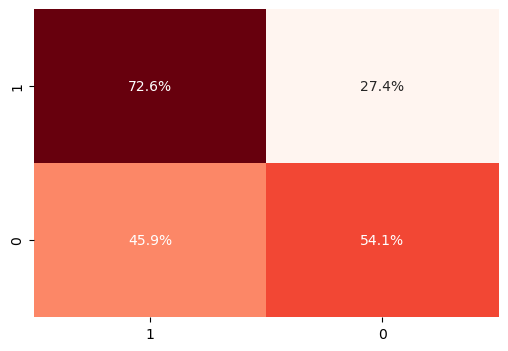

In [10]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

labels = [1, 0]

cm = confusion_matrix(y_val, y_pred, labels=labels)
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_percent = cmn * 100

# Create % signs on confusion matrix
annotations = np.asarray([['{:.1f}%'.format(value) for value in row] for row in cm_percent])

# Plot conusion matrix: with %
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm_percent, annot=annotations, fmt='', cbar=False, cmap='Reds',
            xticklabels=labels, yticklabels=labels)

print(cm)

- True Positive: Almost 73% of positive reviews were correctly predicted as positive = 914
- False Positive: Just over 27% of positive review were incorrectly predicted as negative = 345
- True Negative: Just over 54% of negative reviews were correctly predicted as negative = 671
- False Negative: Almost 46% of negative review were incorrectly predicted as positive = 570

## Part 4: Improve KNN Accuracy
I checked the imporved accuracy of the 3 other models. KNN had the greatest increase in accuracy

- Multinomial Naive Bayes: Old = 77.4% | New = 84%
- Logistic Regression: Old = 77.4% | New = 84%
- Decision Tree: Old = 68% | New = 71%
- K-Nearest Neighbour: Old = 63.4% | New = 74.7%

### How did I improve the Accuracy
Use different class to extract the words in each review as the features the algorithm will learn from = TfidfVectorizer\
Converts text into numerical format, same as Countvectorizer but it also takes into account the frequency of words and how rare or common they are.

- Increase max_features from 500 to 5000
- Each document is represented as a 5000 dimension vector of word counts. Only the 5000 most frequent words are used in this version.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TfidfVectorizer with similar parameters
vectorizer_new = TfidfVectorizer(analyzer="word", max_features=5000, lowercase=True)

# Fit and transform the training data
features_new = vectorizer_new.fit_transform(train_data).toarray()

x_train_new, x_val_new, y_train_new, y_val_new = train_test_split(features_new, train_data_labels, 
                                                                  train_size=0.9, random_state=123)

# Improve KNN's Accuracy
model_new = KNeighborsClassifier(n_neighbors=5)
model_new = model_new.fit(X=x_train_new, y=y_train_new)
y_pred_new = model_new.predict(X=x_val_new)

print(f"Old KNN Accuracy: {accuracy_score(y_val, y_pred)*100}%")
print(f"New KNN Accuracy: {accuracy_score(y_val_new, y_pred_new)*100}%")

Old KNN Accuracy: 63.4%
New KNN Accuracy: 74.68%


## Improved Confusion Matrix

[[923 336]
 [297 944]]


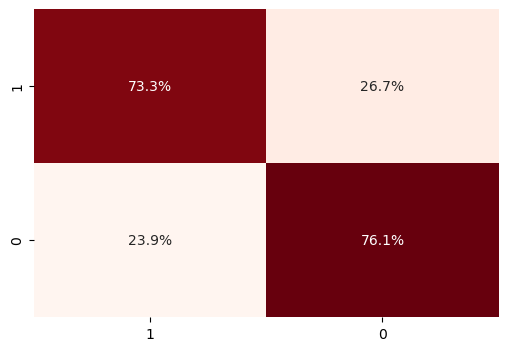

In [12]:
labels = [1, 0]

cm_new = confusion_matrix(y_val_new, y_pred_new, labels=labels)
cmn_new = cm_new.astype('float') / cm_new.sum(axis=1)[:, np.newaxis]
cm_percent_new = cmn_new * 100

# Create % signs on confusion matrix
annotations = np.asarray([['{:.1f}%'.format(value) for value in row] for row in cm_percent_new])

# Plot conusion matrix: with %
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm_percent_new, annot=annotations, fmt='', cbar=False, cmap='Reds',
            xticklabels=labels, yticklabels=labels)

print(cm_new)

- True Positive: Just over 73% of positive reviews were correctly predicted as positive = 923
- False Positive: Almost 27% of positive review were incorrectly predicted as negative = 336
- True Negative: Just over 76% of negative reviews were correctly predicted as negative = 944
- False Negative: Almost 24% of negative review were incorrectly predicted as positive = 297

- **The steps used to increase the accuracy of our KNN algorithim has the greatest affect on predicting negative reviews**
- **True Negative rate was 54% now True Negative rate is 76%**

## Part 5: Using Full IMDB dataset: Testing IMDB Test
- Previously we have been testing and training our model with IMDB train
- Now we will train our model using IMDB train and test our model using IMDB test

In [13]:
imdb_dataset_test = load_dataset("imdb")["test"]
imdb_dataset_train = load_dataset("imdb")["train"]

In [14]:
test_data = imdb_dataset_test["text"]
test_data_labels = imdb_dataset_test["label"]

# Predictions on "New & Improved Model"
test_pred = model_new.predict(vectorizer_new.transform(test_data).toarray())

# Predictions on "Old Model"
test_pred_old = model.predict(vectorizer.transform(test_data).toarray())

print(f"Accuracy of Full New KNN Model: {accuracy_score(test_data_labels, test_pred)*100}%")
print(f"Accuracy of Full Old KNN Model: {accuracy_score(test_data_labels, test_pred_old)*100}%")

Accuracy of Full New KNN Model: 66.096%
Accuracy of Full Old KNN Model: 61.936%


- The model's accuracy drops when testing on the IMDB test dataset
- Drops form 74.68% to 66.096% accuracy
- This could be due to the IMDB train dataset being skewed or representing a specific type of data
- As a result, the model performs better testing on the IMDB train data but struggles to generalize to the IMDB test data

[[7218 5282]
 [3194 9306]]


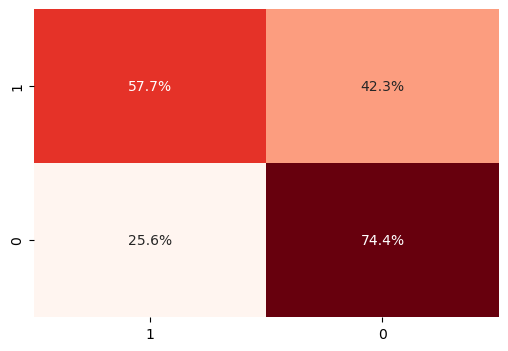

In [15]:
# Confusion Matrix KNN of IMDB test: using previous improved model
labels = [1, 0]

cm = confusion_matrix(test_data_labels, test_pred, labels=labels)
cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_percent = cmn * 100

# Create % signs on confusion matrix
annotations = np.asarray([['{:.1f}%'.format(value) for value in row] for row in cm_percent])

# Plot conusion matrix: with %
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm_percent, annot=annotations, fmt='', cbar=False, cmap='Reds',
            xticklabels=labels, yticklabels=labels)

print(cm)

- True Positive: Almost 58% of positive reviews were correctly predicted as positive = 7218
- False Positive: Just over 42% of positive review were incorrectly predicted as negative = 5282
- True Negative: Just over 74% of negative reviews were correctly predicted as negative = 9306
- False Negative: Almost 26% of negative review were incorrectly predicted as positive = 3194